In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field

pd.set_option('display.max_columns', None)

In [23]:
@dataclass
class Selection:
    name: str
    mask: pd.Series
    events: int = field(init=False)
    interactions: int = field(init=False)

    def __post_init__(self):
        self.events = len(df[self.mask].groupby(level=[0, 1]).size())
        self.interactions = len(df[self.mask].groupby(level=[0, 1, 2]).size())

In [24]:
def broadcast_to_particles(interaction_mask, df):
    s = interaction_mask.loc[df.index.droplevel('rec.dlp.particles..index')]
    s.index = df.index
    return s

In [17]:
with pd.HDFStore('/nashome/m/micarrig/sbnd/nueCCNp/cafpyana/test.df') as store:
    print(store.keys())

['/evt_0', '/evt_1', '/evt_2', '/evt_3', '/evt_4', '/evt_5', '/evt_6', '/hdr_0', '/hdr_1', '/hdr_2', '/hdr_3', '/hdr_4', '/hdr_5', '/hdr_6', '/histgenevtdf_0', '/histgenevtdf_1', '/histgenevtdf_2', '/histgenevtdf_3', '/histgenevtdf_4', '/histgenevtdf_5', '/histgenevtdf_6', '/histpotdf_0', '/histpotdf_1', '/histpotdf_2', '/histpotdf_3', '/histpotdf_4', '/histpotdf_5', '/histpotdf_6', '/mcnu_0', '/mcnu_1', '/mcnu_2', '/mcnu_3', '/mcnu_4', '/mcnu_5', '/mcnu_6', '/pot_0', '/pot_1', '/pot_2', '/pot_3', '/pot_4', '/pot_5', '/pot_6', '/split', '/trk_0', '/trk_1', '/trk_2', '/trk_3', '/trk_4', '/trk_5', '/trk_6']


In [12]:
hdf_path = '/nashome/m/micarrig/sbnd/nueCCNp/cafpyana/test.df'

trks = pd.read_hdf(hdf_path, key='trk_0')

with pd.HDFStore(hdf_path, mode='r') as store:
    print(store.keys())

['/evt_0', '/evt_1', '/evt_2', '/evt_3', '/evt_4', '/evt_5', '/evt_6', '/hdr_0', '/hdr_1', '/hdr_2', '/hdr_3', '/hdr_4', '/hdr_5', '/hdr_6', '/histgenevtdf_0', '/histgenevtdf_1', '/histgenevtdf_2', '/histgenevtdf_3', '/histgenevtdf_4', '/histgenevtdf_5', '/histgenevtdf_6', '/histpotdf_0', '/histpotdf_1', '/histpotdf_2', '/histpotdf_3', '/histpotdf_4', '/histpotdf_5', '/histpotdf_6', '/mcnu_0', '/mcnu_1', '/mcnu_2', '/mcnu_3', '/mcnu_4', '/mcnu_5', '/mcnu_6', '/pot_0', '/pot_1', '/pot_2', '/pot_3', '/pot_4', '/pot_5', '/pot_6', '/split', '/trk_0', '/trk_1', '/trk_2', '/trk_3', '/trk_4', '/trk_5', '/trk_6']


In [14]:
trks

rec  \
                                                             dlp   
                                                       particles   
                                                       match_ids   
                                                                   
__ntuple entry rec.dlp..index rec.dlp.particles..index             
19       0     0              0                                1   
               1              0                               33   
                              1                                4   
               2              0                               18   
               5              0                               28   
...                                                          ...   
13       8826  3              0                                5   
                              1                                4   
                              2                                2   
               4              0                                0   
               5              0                                3   

                                                                       \
                                                                        
                                                                        
                                                       match_overlaps   
                                                                        
__ntuple entry rec.dlp..index rec.dlp.particles..index                  
19       0     0              0                              0.882353   
               1              0                              0.801887   
                              1                              0.664754   
               2              0                              0.648649   
               5              0                              0.668293   
...                                                               ...   
13       8826  3              0                              0.714286   
                              1                              0.880000   
                              2                              0.827985   
               4              0                              0.997245   
               5              0                              0.978178   

                                                                     \
                                                                      
                                                                      
                                                       axial_spread   
                                                                      
__ntuple entry rec.dlp..index rec.dlp.particles..index                
19       0     0              0                                -inf   
               1              0                                -inf   
                              1                                -inf   
               2              0                                -inf   
               5              0                                -inf   
...                                                             ...   
13       8826  3              0                                -inf   
                              1                                -inf   
                              2                                -inf   
               4              0                                -inf   
               5              0                                -inf   

                                                                    \
                                                                     
                                                                     
                                                           calo_ke   
                                                                     
__ntuple entry rec.dlp..index rec.dlp.particles..index               
19       0     0              0   

In [63]:
hdf_path = '/nashome/m/micarrig/sbnd/nueCCNp/cafpyana/test.df'
key = 'evt'

with pd.HDFStore(hdf_path, mode='r') as store:
    chunks = sorted(k for k in store.keys() if k.strip('/').startswith(key))
    print(f"Found {len(chunks)} chunks for key '{key}': {chunks}")
    df = pd.concat([store[k] for k in chunks])

Found 7 chunks for key 'evt': ['/evt_0', '/evt_1', '/evt_2', '/evt_3', '/evt_4', '/evt_5', '/evt_6']


In [64]:
df

rec                                \
                                    dlp                                 
                              match_ids match_overlaps cathode_offset   
                                                                        
                                                                        
__ntuple entry rec.dlp..index                                           
19       4     4                      0       0.839323           -inf   
         8     0                      0       0.831650           -inf   
         12    4                      0       0.956386           -inf   
         21    0                      0       0.820463           -inf   
         25    2                      0       0.948164           -inf   
...                                 ...            ...            ...   
1        8739  4                      0       0.796907           -inf   
         8743  10                     0       0.950000           -inf   
         8745  5                      0       0.884194           -inf   
         8746  7                      0       0.906526           -inf   
         8749  5                      0       0.872000           -inf   

                                                                            \
                                                                             
                              depositions_sum flash_hypo_pe flash_total_pe   
                                                                             
                                                                             
__ntuple entry rec.dlp..index                                                
19       4     4                   638.192200  15947.394441   19606.494025   
         8     0                   126.749374   3219.817154   11127.197000   
         12    4                   183.333649   5025.556555    7393.254825   
         21    0                   266.932953   7520.268593   19769.984725   
         25    2                   168.900116   7411.726568   15155.821250   
...                                       ...           ...            ...   
1        8739  4                   450.653412  10882.760100   20109.126875   
         8743  10                   24.528835    826.390749    2897.322725   
         8745  5                   152.381775   3641.501221    4895.138275   
         8746  7                   658.512329  15135.027132   20394.839325   
         8749  5                   132.016907   2751.772688   13586.362850   

                                                                               \
                                                                                
                               id is_cathode_crosser is_contained is_fiducial   
                                                                                
                                                                                
__ntuple entry rec.dlp..index                                                   
19       4     4                4                  0            1           1   
         8     0                0                  0            1           1   
         12    4                4                  0            1           1   
         21    0                0                  0            1           1   
         25    2                2                  0            1           1   
...                            ..                ...          ...         ...   
1        8739  4                4                  0            1           1   
         8743  10              10                  0            1           1   
         8745  5                5                  0            1           1   
         8746  7                7                  0            1           1   
         8749  5                5                  0            1           1   

                                                                             \
          

In [55]:
hdf_path = '/nashome/m/micarrig/sbnd/nueCCNp/cafpyana/test.df'
key = 'mcnu'

with pd.HDFStore(hdf_path, mode='r') as store:
    chunks = sorted(k for k in store.keys() if k.strip('/').startswith(key))
    df = pd.concat([store[k] for k in chunks])

In [60]:
df['e'].keys()

MultiIndex([(          'genE',  ''),
            (        'length',  ''),
            (           'pdg',  ''),
            (          'genp', 'x'),
            (          'genp', 'y'),
            (          'genp', 'z'),
            (         'start', 'x'),
            (         'start', 'y'),
            (         'start', 'z'),
            (           'end', 'x'),
            (           'end', 'y'),
            (           'end', 'z'),
            ('interaction_id',  ''),
            (   'crosses_tpc',  ''),
            (     'contained',  '')],
           )

In [62]:
df[~df.e.genE.isna()]

E    baseline      time  bjorkenX  \
                                                                            
                                                                            
__ntuple entry rec.mc.nu..index                                             
19       4     0                 1.165430   84.509583  1.573447  0.645055   
         22    1                 0.880080  132.435699  0.894193  0.145126   
         143   2                 1.707558  114.062668  1.111105  0.462537   
         193   0                 1.397519   98.125557  1.009407  0.462894   
         400   2                 1.928793  100.563477  0.385781  0.456933   
...                                   ...         ...       ...       ...   
1        8397  1                 3.648701   91.507172  1.674173  0.184838   
         8450  1                 2.065669  101.614052  1.653633  0.507733   
         8629  0                 1.916506  117.077621  1.739245  0.251328   
         8708  0                 1.163393   93.401787  1.415236  0.298450   
         8723  0                 0.769645  106.672813  1.640645  0.237748   

                                inelasticityY        Q2         w  momentum  \
                                                                          x   
                                                                              
__ntuple entry rec.mc.nu..index                                               
19       4     0                     0.530631  0.749089  1.137435  0.013692   
         22    1                     0.553770  0.132818  1.289937 -0.009408   
         143   2                     0.275474  0.408564  1.164610 -0.073980   
         193   0                     0.166222  0.201922  1.056345 -0.021646   
         400   2                     0.866661  1.434319  1.608186  0.076093   
...                                       ...       ...       ...       ...   
1        8397  1                     0.427933  0.541955  1.808776 -0.011958   
         8450  1                     0.416249  0.819798  1.294757 -0.024418   
         8629  0                     0.439447  0.397480  1.437222 -0.000594   
         8708  0                     0.063838  0.041623  0.989652  0.012392   
         8723  0                     0.776430  0.266789  1.317926 -0.005180   

                                                       position              \
                                        y         z           x           y   
                                                                              
__ntuple entry rec.mc.nu..index                                               
19       4     0                -0.031483  1.164925  -21.654102 -173.859360   
         22    1                 0.006265  0.880007 -198.535110   80.640808   
         143   2                -0.028537  1.705716 -494.050598 -203.151947   
         193   0                 0.051831  1.396390 -259.168854  301.006256   
         400   2                 0.048691  1.926676  245.327972  224.230255   
...                                   ...       ...         ...         ...   
1        8397  1                -0.027313  3.648579  -88.839729  -85.320366   
         8450  1                -0.179210  2.057735 -221.869537 -693.022339   
         8629  0                 0.037073  1.916148  -77.105942  188.686874   
         8708  0                 0.030610  1.162924  -37.670540  177.253372   
         8723  0                -0.004479  0.769615 -150.662567  -35.721676   

                                            pdg iscc genie_mode parent_pdg  \
                                          z                                  
                                                                             
__ntuple entry rec.mc.nu..index                                              
19       4     0                 219.513062  12    1          0        321   
         22    1                 486.509186  12    1          1        321   
         143   2                 626.691101 

In [39]:
key = 'hdr'
with pd.HDFStore(hdf_path, mode='r') as store:
    chunks = sorted(k for k in store.keys() if k.strip('/').startswith(key))
    pot = pd.concat([store[k] for k in chunks])

In [40]:
POT = pot['pot'].sum()

In [ ]:
true_particle_idx = df.index.get_level_values('rec.dlp.particles..index')
true_prim_muon_mask = true_particle_idx == df.rec.dlp_true.primmm # get mask of only primary muons
true_prim_pion_mask = true_particle_idx == df.rec.dlp_true.primmp # get mask of only primary pions
true_prim_ele_mask = true_particle_idx == df.rec.dlp_true.primele # get mask of only primary electrons
true_prim_proton_mask = true_particle_idx == df.rec.dlp_true.primpr # get mask of only primary protons
true_prim_photon_mask = true_particle_idx == df.rec.dlp_true.primph # get mask of only primary photons


KeyError: 'Level rec.dlp_true.particles..index not found'

In [32]:
# particle_idx = df.index.get_level_values('rec.dlp.particles..index') # get index for all particles
# prim_muon_mask = particle_idx == df.rec.dlp.primmu # get mask of only primary muons
# prim_pion_mask = particle_idx == df.rec.dlp.primpi # get mask of only primary pions
# prim_ele_mask = particle_idx == df.rec.dlp.primele # get mask of only primary electrons
# prim_proton_mask = particle_idx == df.rec.dlp.primpr # get mask of only primary protons
# prim_photon_mask = particle_idx == df.rec.dlp.primph # get mask of only primary photons

all_mask = pd.Series(True, index=df.index) # mask of all particles

# preselection interaction level masks
fid_mask = df.rec.dlp['is_fiducial'] == 1
flash_mask = df.rec.dlp['is_flash_matched'] == 1
contained_mask = df.rec.dlp['is_contained'] == 1
muon_mask = df.rec.dlp['muon_mask_reco'] == 0
pion_mask = df.rec.dlp['pion_mask_reco'] == 0
photon_mask = df.rec.dlp['photon_mask_reco'] == 0
electron_mask = df.rec.dlp['ele_mask_reco'] == 1
proton_mask = df.rec.dlp['proton_mask_reco'] == 1
electron_softmax_mask = df.rec.dlp['ele_softmax_reco'] > 0.9
electron_primary_mask = df.rec.dlp['ele_primary_reco'] > 0.99
proton_softmax_mask = df.rec.dlp['proton_softmax_reco'] > 0.75
vertex_distance_mask = df.rec.dlp['ele_vertex_distance_reco']  < 3.5
dedx_mask = df.rec.dlp['ele_dedx_reco'] < 4

# # Particle level masks
# muon_mask = (abs(df.rec.dlp.particles['pdg_code'] == 13) & (df.rec.dlp.particles['is_primary'] == 1) & (df.rec.dlp.particles['calo_ke'] > 25.0))
# pion_mask = (abs(df.rec.dlp.particles['pdg_code'] == 211) & (df.rec.dlp.particles['is_primary'] == 1) & (df.rec.dlp.particles['calo_ke'] > 25.0))
# photon_mask = (abs(df.rec.dlp.particles['pdg_code'] == 22) & (df.rec.dlp.particles['is_primary'] == 1) & (df.rec.dlp.particles['calo_ke'] > 100.0))  
# electron_mask = (abs(df.rec.dlp.particles['pdg_code'] == 11) & (df.rec.dlp.particles['is_primary'] == 1) & (df.rec.dlp.particles['calo_ke'] > 500.0))
# proton_mask = (abs(df.rec.dlp.particles['pdg_code'] == 2212) & (df.rec.dlp.particles['is_primary'] == 1) & (df.rec.dlp.particles['calo_ke'] > 40.0))
# electron_softmax_mask = df.rec.dlp.particles.pid_scores['I1'] > 0.9
# electron_primary_mask = df.rec.dlp.particles.primary_scores['I1'] > 0.99
# proton_softmax_mask = df.rec.dlp.particles.pid_scores['I4'] > 0.75
# vertex_distance_mask = df.rec.dlp.particles.vertex_distance < 3.5
# dedx_mask = df.rec.dlp.particles.start_dedx < 4.0

# # Interaction level mask from particle level masks
# int_muon_mask = broadcast_to_particles((prim_muon_mask & muon_mask).groupby(level=[0, 1, 2]).any(), df)
# int_pion_mask = broadcast_to_particles((prim_pion_mask & pion_mask).groupby(level=[0, 1, 2]).any(), df)
# int_ele_mask = broadcast_to_particles((prim_ele_mask & electron_mask).groupby(level=[0, 1, 2]).any(), df)
# int_proton_mask = broadcast_to_particles((prim_proton_mask & proton_mask).groupby(level=[0, 1, 2]).any(), df)
# int_photon_mask = broadcast_to_particles((prim_photon_mask & photon_mask).groupby(level=[0, 1, 2]).any(), df)
# int_ele_sm_mask = broadcast_to_particles((prim_ele_mask & electron_softmax_mask).groupby(level=[0, 1, 2]).any(), df)
# int_ele_primary_mask = broadcast_to_particles((prim_ele_mask & electron_primary_mask).groupby(level=[0, 1, 2]).any(), df)
# int_proton_sm_mask = broadcast_to_particles((prim_proton_mask & proton_softmax_mask).groupby(level=[0, 1, 2]).any(), df)
# int_vertex_distance_mask = broadcast_to_particles((prim_ele_mask & vertex_distance_mask).groupby(level=[0, 1, 2]).any(), df)
# int_dedx_mask = broadcast_to_particles((prim_ele_mask & dedx_mask).groupby(level=[0, 1, 2]).any(), df)

In [42]:
selections = []

selections.append(Selection(name='No Selection', mask=all_mask))
selections.append(Selection(name='Fiducial Volume', mask=fid_mask))
selections.append(Selection(name='Flash Matched', mask=flash_mask))
selections.append(Selection(name='Contained', mask=contained_mask))
selections.append(Selection(name='No Muons > 25 MeV', mask=muon_mask))
selections.append(Selection(name='No Pions > 25 MeV', mask=pion_mask))
selections.append(Selection(name='Electrons > 500 MeV', mask=electron_mask))
selections.append(Selection(name='Protons > 40 MeV', mask=proton_mask))
selections.append(Selection(name='No Photons > 100 MeV', mask=photon_mask))
selections.append(Selection(name='Electron Softmax > 0.9', mask=electron_softmax_mask))
selections.append(Selection(name='Electron Primary > 0.99', mask=electron_primary_mask))
selections.append(Selection(name='Proton Softmax > 0.75', mask=proton_softmax_mask))
selections.append(Selection(name='Vertex Distance < 3.5', mask=vertex_distance_mask))
selections.append(Selection(name='dE/dx < 4.0', mask=dedx_mask))

In [43]:
W = 28  # column width for metric columns

header = (f"{'Selection':<30} {'Events':>10} {'Ints':>10} "
          f"{'Diff. Eff.':>{W}} {'Cum. Eff.':>{W}} {'Purity':>{W}}")
print(header)
print("-" * len(header))

combined_sel = all_mask.copy()
signal = df.rec.dlp_true.true_signal1p | df.rec.dlp_true.true_signalNp
signal_interactions = len(df[signal].groupby(level=[0, 1, 2]).size())

for sel in selections:
    combined_sel &= sel.mask
    evts     = len(df[sel.mask].groupby(level=[0, 1]).size())
    ints     = len(df[sel.mask].groupby(level=[0, 1, 2]).size())
    sig_ints = len(df[sel.mask & signal].groupby(level=[0, 1, 2]).size())
    ints_cum     = len(df[combined_sel].groupby(level=[0, 1, 2]).size())
    cum_sig_ints = len(df[combined_sel & signal].groupby(level=[0, 1, 2]).size())

    diff_eff = sig_ints / signal_interactions if signal_interactions > 0 else 0
    cum_eff  = cum_sig_ints / signal_interactions if signal_interactions > 0 else 0
    purity   = cum_sig_ints / ints_cum if ints_cum > 0 else 0

    diff_str = f"{diff_eff:.1%} ({sig_ints}/{signal_interactions})"
    cum_str  = f"{cum_eff:.1%} ({cum_sig_ints}/{signal_interactions})"
    pur_str  = f"{purity:.1%} ({cum_sig_ints}/{ints_cum})"

    print(f"{sel.name:<30} {evts:>10} {ints:>10} "
          f"{diff_str:>{W}} {cum_str:>{W}} {pur_str:>{W}}")

Selection                          Events       Ints                   Diff. Eff.                    Cum. Eff.                       Purity
-------------------------------------------------------------------------------------------------------------------------------------------
No Selection                        56121      56335             100.0% (160/160)             100.0% (160/160)             0.3% (160/56335)
Fiducial Volume                     56121      56335             100.0% (160/160)             100.0% (160/160)             0.3% (160/56335)
Flash Matched                       56121      56335             100.0% (160/160)             100.0% (160/160)             0.3% (160/56335)
Contained                           56121      56335             100.0% (160/160)             100.0% (160/160)             0.3% (160/56335)
No Muons > 25 MeV                   27729      27807             100.0% (160/160)             100.0% (160/160)             0.6% (160/27807)
No Pions > 25 MeV   

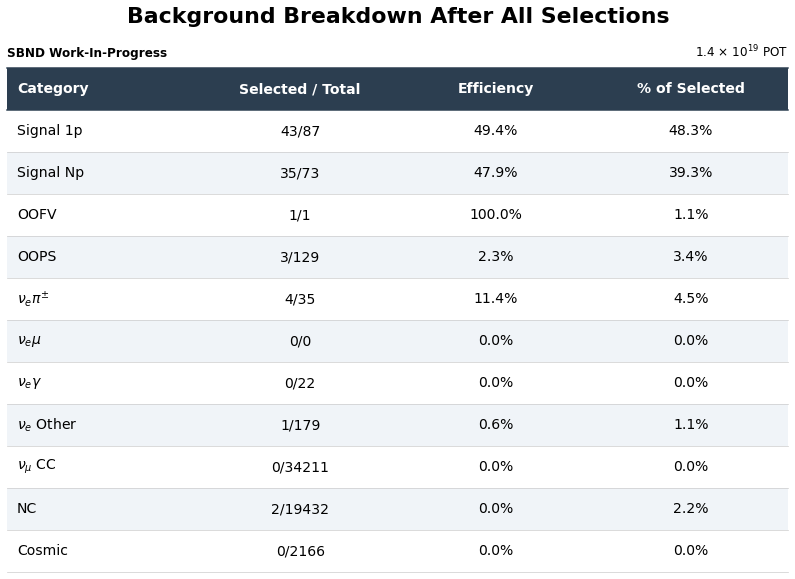

In [54]:
total_selected = len(df[combined_sel].groupby(level=[0, 1, 2]).size())

categories = {
    'Signal 1p': df.rec.dlp_true.true_signal1p,
    'Signal Np': df.rec.dlp_true.true_signalNp,
    'OOFV': df.rec.dlp_true.bkgd_oofv,
    'OOPS': df.rec.dlp_true.bkgd_oops,
    r'$\nu_e \pi^{\pm}$': df.rec.dlp_true.bkgd_pi,
    r'$\nu_e \mu$': df.rec.dlp_true.bkgd_mu,
    r'$\nu_e \gamma$': df.rec.dlp_true.bkgd_photon,
    r'$\nu_e$ Other': df.rec.dlp_true.bkgd_nueOther,
    r'$\nu_{\mu}$ CC': df.rec.dlp_true.bkgd_numu,
    'NC': df.rec.dlp_true.bkgd_nc,
    'Cosmic': df.rec.dlp_true.bkgd_other,
}

rows = []
for k, v in categories.items():
    total    = len(df[v].groupby(level=[0, 1, 2]).size())
    selected = len(df[combined_sel & v].groupby(level=[0, 1, 2]).size())
    eff      = selected / total if total > 0 else 0
    frac     = selected / total_selected if total_selected > 0 else 0
    rows.append([k,
                 f"{selected}/{total}",
                 f"{eff:.1%}",
                 f"{frac:.1%}"])

col_labels = ['Category', 'Selected / Total', 'Efficiency', '% of Selected']

coeff, exp = f'{POT:.1e}'.split('e')
luminosity = rf'{coeff} $\times$ 10$^{{{int(exp)}}}$ POT'

fig, ax = plt.subplots(figsize=(14, len(rows) * 0.55 + 1.5))
ax.axis('off')

table = ax.table(cellText=rows, colLabels=col_labels, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1, 3.5)

for key, cell in table.get_celld().items():
    cell.set_linewidth(0)

for i in range(1, len(rows) + 1):
    bg = '#f0f4f8' if i % 2 == 0 else 'white'
    for j in range(len(col_labels)):
        table[i, j].set_facecolor(bg)

for i in range(1, len(rows) + 1):
    table[i, 0].set_text_props(ha='left')
    table[i, 0].PAD = 0.05

for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')
table[0, 0].set_text_props(ha='left', color='white', fontweight='bold')
table[0, 0].PAD = 0.05

fig.canvas.draw()
renderer = fig.canvas.get_renderer()
ax_bbox = ax.get_window_extent(renderer)

def hline(row_idx, use_top, color, lw):
    c0 = table[row_idx, 0].get_window_extent(renderer)
    cn = table[row_idx, len(col_labels) - 1].get_window_extent(renderer)
    y  = ((c0.y1 if use_top else c0.y0) - ax_bbox.y0) / ax_bbox.height
    x0 = (c0.x0 - ax_bbox.x0) / ax_bbox.width
    x1 = (cn.x1 - ax_bbox.x0) / ax_bbox.width
    ax.plot([x0, x1], [y, y], color=color, lw=lw, transform=ax.transAxes, clip_on=False)

hline(0, use_top=True,  color='#2c3e50', lw=1.5)
hline(0, use_top=False, color='#2c3e50', lw=1.5)
for i in range(1, len(rows) + 1):
    hline(i, use_top=False, color='#cccccc', lw=0.7)

x_left   = (table[0, 0].get_window_extent(renderer).x0 - ax_bbox.x0) / ax_bbox.width
x_right  = (table[0, len(col_labels)-1].get_window_extent(renderer).x1 - ax_bbox.x0) / ax_bbox.width
x_center = (x_left + x_right) / 2
y_table_top = (table[0, 0].get_window_extent(renderer).y1 - ax_bbox.y0) / ax_bbox.height

ax.text(x_left,   y_table_top + 0.02, 'SBND Work-In-Progress', transform=ax.transAxes,
        ha='left', va='bottom', fontweight='bold', fontsize=12)
ax.text(x_right,  y_table_top + 0.02, luminosity, transform=ax.transAxes,
        ha='right', va='bottom', fontsize=12)
ax.text(x_center, y_table_top + 0.10, r'Background Breakdown After All Selections',
        transform=ax.transAxes, ha='center', va='bottom', fontsize=22, fontweight='bold')

plt.savefig('bkgd_breakdown_table.png', dpi=150, bbox_inches='tight')
plt.show()

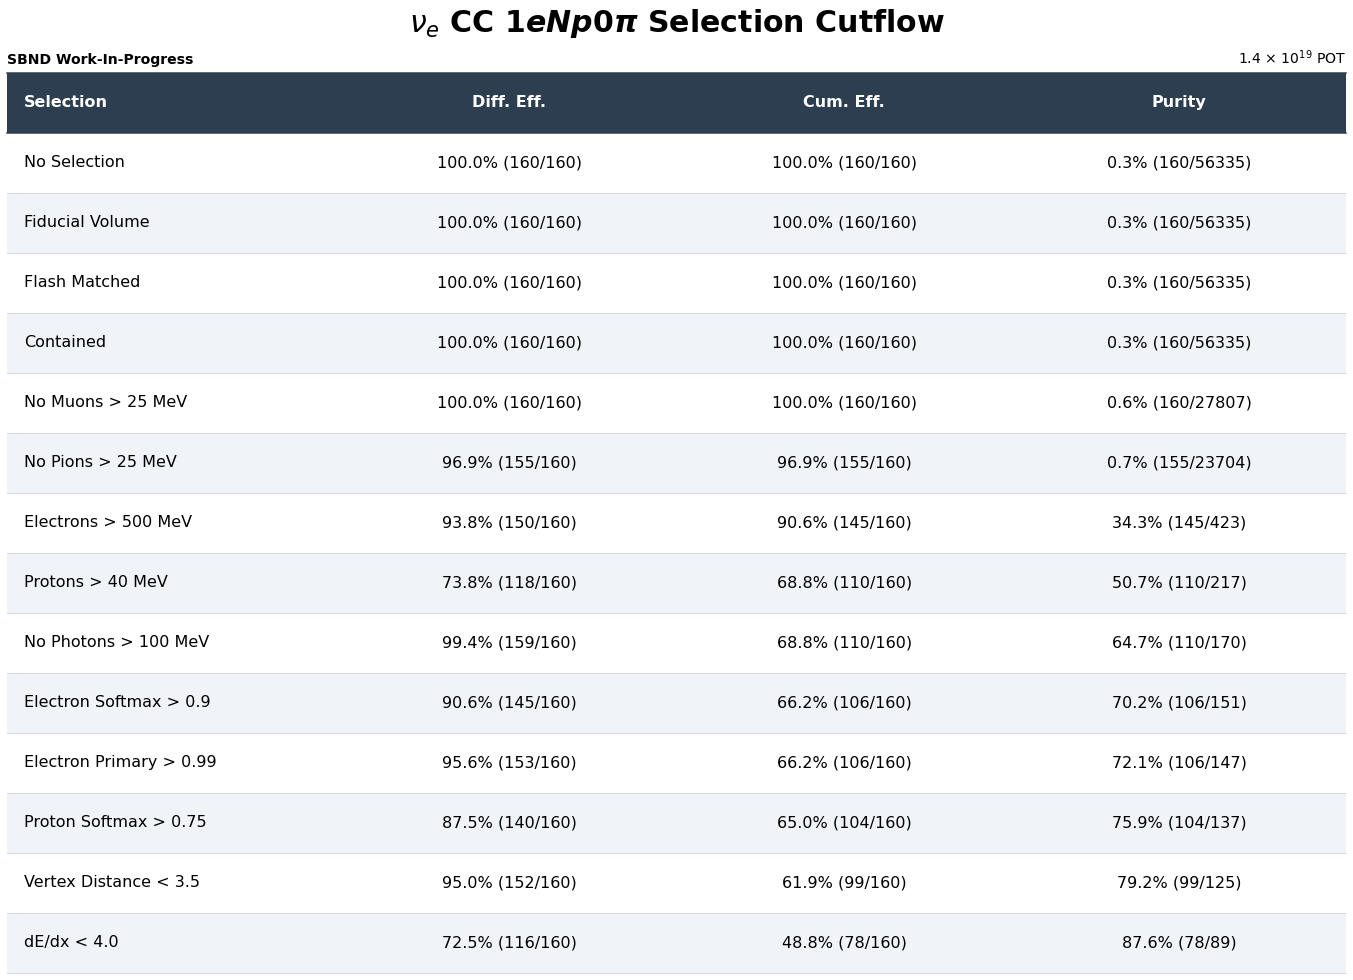

In [44]:
# Build table data
rows = []
combined_sel = all_mask.copy()
signal = df.rec.dlp_true.true_signal1p | df.rec.dlp_true.true_signalNp
signal_interactions = len(df[signal].groupby(level=[0, 1, 2]).size())

for sel in selections:
    combined_sel &= sel.mask
    evts     = len(df[sel.mask].groupby(level=[0, 1]).size())
    ints     = len(df[sel.mask].groupby(level=[0, 1, 2]).size())
    sig_ints = len(df[sel.mask & signal].groupby(level=[0, 1, 2]).size())
    ints_cum     = len(df[combined_sel].groupby(level=[0, 1, 2]).size())
    cum_sig_ints = len(df[combined_sel & signal].groupby(level=[0, 1, 2]).size())

    diff_eff = sig_ints / signal_interactions if signal_interactions > 0 else 0
    cum_eff  = cum_sig_ints / signal_interactions if signal_interactions > 0 else 0
    purity   = cum_sig_ints / ints_cum if ints_cum > 0 else 0

    rows.append([
        sel.name, 
        # evts, 
        # ints,
        f"{diff_eff:.1%} ({sig_ints}/{signal_interactions})",
        f"{cum_eff:.1%} ({cum_sig_ints}/{signal_interactions})",
        f"{purity:.1%} ({cum_sig_ints}/{ints_cum})",
    ])

col_labels = ['Selection', 
            # 'Total Events', 
            # 'Total Interactions', 
            'Diff. Eff.', 
            'Cum. Eff.', 
            'Purity']

coeff, exp = f'{POT:.1e}'.split('e')
luminosity = rf'{coeff} $\times$ 10$^{{{int(exp)}}}$ POT'

fig, ax = plt.subplots(figsize=(24, 5))
ax.axis('off')

table = ax.table(cellText=rows, colLabels=col_labels, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(16)
table.scale(1, 5.0)

# Remove ALL cell borders
for key, cell in table.get_celld().items():
    cell.set_linewidth(0)

# Alternating row shading (data rows only)
for i in range(1, len(rows) + 1):
    bg = '#f0f4f8' if i % 2 == 0 else 'white'
    for j in range(len(col_labels)):
        table[i, j].set_facecolor(bg)

# Left-align Selection column (data rows only)
for i in range(1, len(rows) + 1):
    table[i, 0].set_text_props(ha='left')
    table[i, 0].PAD = 0.05

# Header styling
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')
table[0, 0].set_text_props(ha='left', color='white', fontweight='bold')
table[0, 0].PAD = 0.05

fig.canvas.draw()
renderer = fig.canvas.get_renderer()
ax_bbox = ax.get_window_extent(renderer)

def hline(row_idx, use_top, color, lw):
    c0 = table[row_idx, 0].get_window_extent(renderer)
    cn = table[row_idx, len(col_labels) - 1].get_window_extent(renderer)
    y  = ((c0.y1 if use_top else c0.y0) - ax_bbox.y0) / ax_bbox.height
    x0 = (c0.x0 - ax_bbox.x0) / ax_bbox.width
    x1 = (cn.x1 - ax_bbox.x0) / ax_bbox.width
    ax.plot([x0, x1], [y, y], color=color, lw=lw, transform=ax.transAxes, clip_on=False)

hline(0, use_top=True,  color='#2c3e50', lw=1.5)
hline(0, use_top=False, color='#2c3e50', lw=1.5)
for i in range(1, len(rows) + 1):
    hline(i, use_top=False, color='#cccccc', lw=0.7)

# All labels positioned relative to the table top
x_left   = (table[0, 0].get_window_extent(renderer).x0 - ax_bbox.x0) / ax_bbox.width
x_right  = (table[0, len(col_labels)-1].get_window_extent(renderer).x1 - ax_bbox.x0) / ax_bbox.width
x_center = (x_left + x_right) / 2
y_table_top = (table[0, 0].get_window_extent(renderer).y1 - ax_bbox.y0) / ax_bbox.height

ax.text(x_left,   y_table_top + 0.02, 'SBND Work-In-Progress', transform=ax.transAxes,
        ha='left', va='bottom', fontweight='bold', fontsize=14)
ax.text(x_right,  y_table_top + 0.02, luminosity, transform=ax.transAxes,
        ha='right', va='bottom', fontsize=14)
ax.text(x_center, y_table_top + 0.12, r'$\boldsymbol{\nu_e}$ CC $\boldsymbol{1eNp0\pi}$ Selection Cutflow',
        transform=ax.transAxes, ha='center', va='bottom', fontsize=30, fontweight='bold')

plt.savefig('cutflow_table.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# ele_prim_score = df.rec.dlp.particles.primary_scores['I0'][mask]
len(df[mask].groupby(level=[0, 1]).size())

107

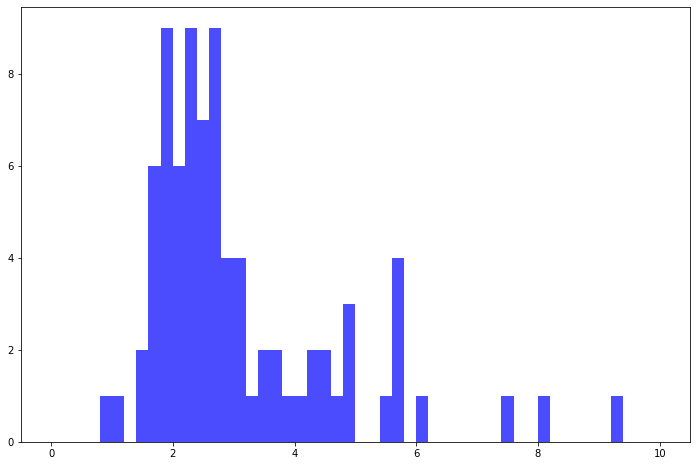

In [23]:
plt.figure(figsize=(12, 8))

ele_dedx = df.rec.dlp.particles['start_dedx'][mask]
ele_dedx_int = ele_dedx.groupby(level=[0, 1, 2]).first()

plt.hist(ele_dedx_int, bins=50, range=(0, 10), histtype='stepfilled', alpha=0.7, color='blue')
plt.show()

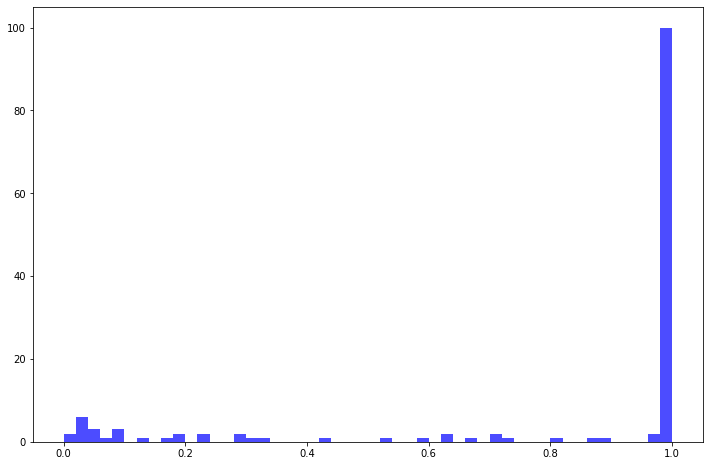

In [16]:
plt.figure(figsize=(12, 8))

ele_prim_score = df.rec.dlp.particles.primary_scores['I1'][mask]
ele_prim_score_int = ele_prim_score.groupby(level=[0, 1, 2]).first()

plt.hist(ele_prim_score_int, bins=50, range=(0, 1), histtype='stepfilled', alpha=0.7, color='blue')
plt.show()


In [177]:
evts = df.groupby(level=[0, 1]).size() #number of events
interactions = df.groupby(level=[0, 1, 2]).size() #number of interactions
particles = df.groupby(level=[0, 1, 2, 3]).size() #number of particles

print("Total Events: ", len(evts))
print("Total Interactions: ", len(interactions))
print("Total Particles: ", len(particles))

Total Events:  8832
Total Interactions:  98639
Total Particles:  324845


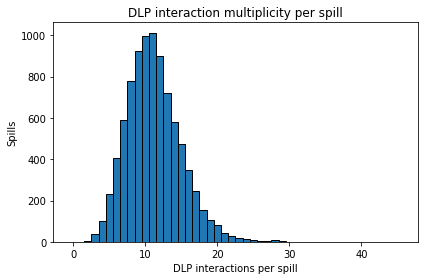

In [122]:
interactions_per_spill = df.groupby(level=[0, 1, 2]).size()  # one row per interaction
counts = interactions_per_spill.groupby(level=[0, 1]).size()  # count interactions per spill

fig, ax = plt.subplots()
ax.hist(counts, bins=range(counts.max() + 2), align='left', edgecolor='black')
ax.set_xlabel('DLP interactions per spill')
ax.set_ylabel('Spills')
ax.set_title('DLP interaction multiplicity per spill')
plt.tight_layout()
plt.show()

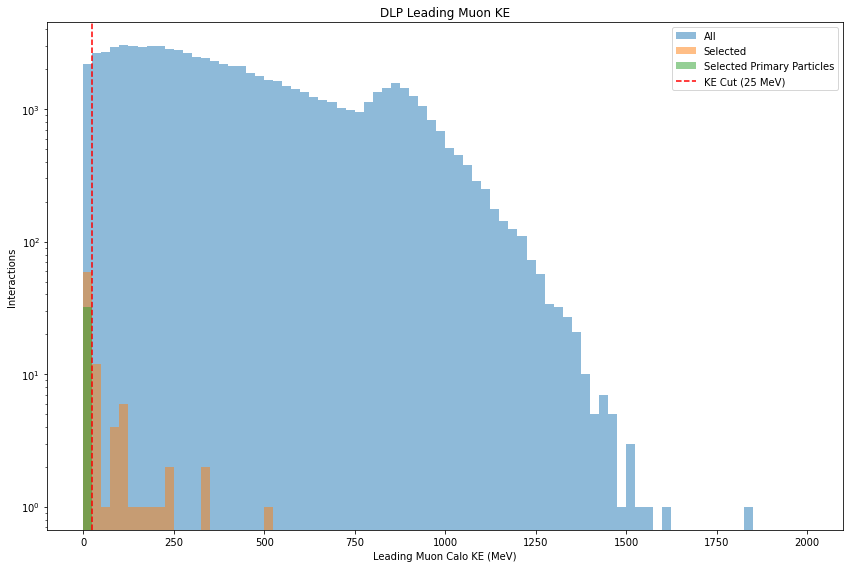

In [153]:
particle_idx = df.index.get_level_values('rec.dlp.particles..index')
prim_muon_mask = particle_idx == df.rec.dlp.primmu

muon_ke = df.rec.dlp.particles.calo_ke[prim_muon_mask]

sel_mask = fid_mask & flash_mask & contained_mask & ~muon_mask
muon_sel = sel_mask & prim_muon_mask

primary_mask = df.rec.dlp.particles.is_primary == 1

muon_ke_sel = df.rec.dlp.particles.calo_ke[muon_sel]

prim_muon_ke_sel = df.rec.dlp.particles.calo_ke[muon_sel & primary_mask]

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.hist(muon_ke, bins=80, range=(0, 2000), alpha=0.5, label='All')
ax.hist(muon_ke_sel, bins=80, range=(0, 2000), alpha=0.5, label='Selected')
ax.hist(prim_muon_ke_sel, bins=80, range=(0, 2000), alpha=0.5, label='Selected Primary Particles')
ax.set_xlabel('Leading Muon Calo KE (MeV)')
ax.set_ylabel('Interactions')
ax.set_title('DLP Leading Muon KE')
plt.tight_layout()
plt.yscale('log')

plt.axvline(25.0, color='red', linestyle='--', label='KE Cut (25 MeV)')
plt.legend()

plt.show()


In [144]:
df[~muon_mask]

rec  \
                                                             dlp   
                                                       match_ids   
                                                                   
                                                                   
__ntuple entry rec.dlp..index rec.dlp.particles..index             
0        0     0              0                              5.0   
                              1                              5.0   
               1              0                              0.0   
               2              0                              4.0   
                              1                              4.0   
...                                                          ...   
         8831  22             1                              0.0   
                              2                              0.0   
                              3                              0.0   
                              4                              0.0   
               23             0                             17.0   

                                                                       \
                                                                        
                                                       match_overlaps   
                                                                        
                                                                        
__ntuple entry rec.dlp..index rec.dlp.particles..index                  
0        0     0              0                              0.341244   
                              1                              0.341244   
               1              0                              0.938068   
               2              0                              0.928590   
                              1                              0.928590   
...                                                               ...   
         8831  22             1                              0.896471   
                              2                              0.896471   
                              3                              0.896471   
                              4                              0.896471   
               23             0                              0.769231   

                                                                       \
                                                                        
                                                       cathode_offset   
                                                                        
                                                                        
__ntuple entry rec.dlp..index rec.dlp.particles..index                  
0        0     0              0                                  -inf   
                              1                                  -inf   
               1              0                             -0.250012   
               2              0                                  -inf   
                              1                                  -inf   
...                                                               ...   
         8831  22             1                                  -inf   
                              2                                  -inf   
                              3                                  -inf   
                              4                                  -inf   
               23             0                                  -inf   

                                                                        \
                                                                         
                                                       depositions_sum   
                                                                         
                                                                         
__ntuple entry rec.dlp..index rec.dlp.particles..i